In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
cwd = os.getcwd()
if os.path.basename(cwd) == 'notes':
    os.chdir('..')
print('当前工作目录:', os.getcwd())

当前工作目录: d:\github\prediction


训练集: (34741, 39)  |  测试集: (401, 39)
精炼特征维度: 37 维 (原 552 维)
特征列表: ['pm_t-1', 'pm_t-2', 'pm_t-3', 'pm_t-6', 'pm_t-12', 'pm_t-24', 'DEWP_t', 'HUMI_t', 'PRES_t', 'TEMP_t', 'Iws_t', 'precipitation_t', 'Iprec_t', 'DEWP_mean6', 'HUMI_mean6', 'PRES_mean6', 'TEMP_mean6', 'Iws_mean6', 'precipitation_mean6', 'Iprec_mean6', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'cbwd_cv', 'cbwd_SE', 'cbwd_NW', 'cbwd_SW', 'cbwd_NE', 'pm_roll6_mean', 'pm_roll6_std', 'pm_roll24_mean', 'pm_roll24_std', 'pm_diff_short', 'pm_diff_long']
训练集: 27792  |  验证集: 6949  |  测试集: 401 (训练时不碰)
训练特征: (27768, 37)  |  验证特征: (6949, 37)  |  每行 37 维
Std 下限保护: roll6_std >= 0.0897, roll24_std >= 0.2081
预测裁剪: [3, 224] ug/m3
[0]	train-rmse:0.75863	eval-rmse:0.62157
[20]	train-rmse:0.45675	eval-rmse:0.36445
[40]	train-rmse:0.31063	eval-rmse:0.23964
[60]	train-rmse:0.24775	eval-rmse:0.18616
[80]	train-rmse:0.22303	eval-rmse:0.16554
[100]	train-rmse:0.21302	eval-rmse:0.15776
[120]	train-rmse:0.20829

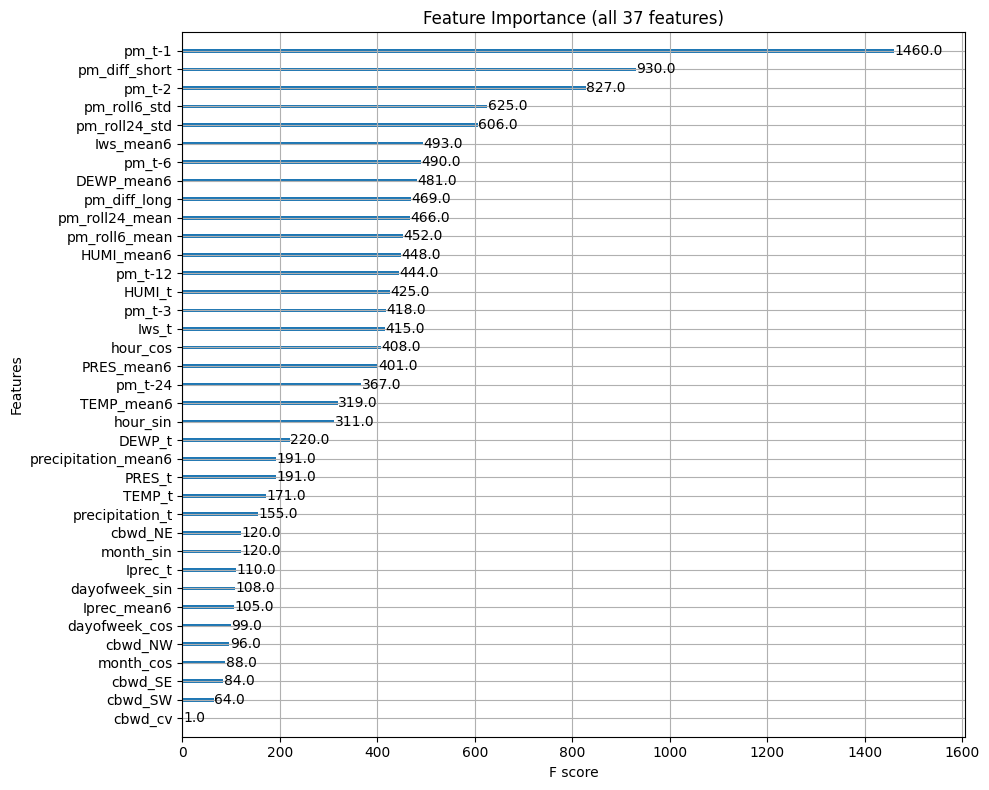


模型训练完成, 进入 4 组评估...


In [22]:
# ============================================================
# XGBoost 时序预测 — 特征精炼降维版 (552维 → 35维)
# 官方文档 API: DMatrix → xgb.train → bst.predict
#   参数参考: https://xgboost.readthedocs.io/en/stable/parameter.html
#   Python API: https://xgboost.readthedocs.io/en/stable/python/python_api.html
#
# 特征设计 (不再展平 24 步 × 23 通道):
#   1. PM2.5 特定滞后: t-1, t-2, t-3, t-6, t-12, t-24        (6 维)
#   2. 气象当前时刻 t: DEWP/HUMI/PRES/TEMP/Iws/precip/Iprec   (7 维)
#   3. 气象短期均值 mean6: 上述 7 量的 6h 滚动均值            (7 维)
#   4. 时间周期编码: hour/month/dayofweek 的 sin+cos          (6 维)
#   5. 风向独热 cbwd: 5 类                                    (5 维)
#   6. PM rolling 统计量: roll6/24 mean+std                   (4 维)
#   合计: 35 维
#
# 稳定性修复 (递归预测防发散):
#   - 隐患1: resample('1h') 补齐时间轴 + interpolate, 彻底消除 dropna 错位
#   - 隐患4: 气象缺失值时间插值 (precipitation 训练集 3865 NaN)
#   - 隐患5: 验证集带 24h 上下文, 不丢失 lag 历史
#   - 隐患6: max_depth 5->4, min_child_weight 10->20, 防误差滚雪球
#   - 隐患2: rolling std 设下限保护, 防 OOD 发散
#   - 隐患3: 移除 sigma2/2 偏置修正 (1步方差不适用72步递归)
# ============================================================

# --- 1. 读取原始数据 ---
df_train_raw = pd.read_csv('data/ShanghaiPM_Training.csv', na_values='NA')
df_test_raw  = pd.read_csv('data/ShanghaiPM_Test.csv',  na_values='NA')

# --- 2. 数据清洗 + 特征工程 ---
# 气象外生变量列表
WEATHER_COLS = ['DEWP', 'HUMI', 'PRES', 'TEMP', 'Iws', 'precipitation', 'Iprec']
WEATHER_MEAN6_COLS = [f'{c}_mean6' for c in WEATHER_COLS]

def preprocess(df):
    """预处理: 补齐时间轴 → 插值 → pm_ave(log) → 三角编码 → 独热 → rolling"""
    df['datetime'] = pd.to_datetime(
        {'year': df['year'], 'month': df['month'], 'day': df['day'], 'hour': df['hour']})
    df = df.set_index('datetime').sort_index()

    # --- 修复隐患1: 补齐完整 1h 时间轴 (不再 dropna, 消除时序错位) ---
    # 原 dropna 删除全缺失 PM 行 → 训练集产生 128 处 2-3h 缺口 → lag 错位
    # 现在: reindex 到完整小时索引, 缺失行用 NaN 填充, 后续统一插值
    full_idx = pd.date_range(df.index[0], df.index[-1], freq='1h')
    df = df.reindex(full_idx)

    # --- 气象外生变量缺失值填补 (修复隐患4: 防 NaN 污染 rolling 均值) ---
    # precipitation/Iprec 在训练集有 ~3865 个 NaN, 测试集有 144 个
    df[WEATHER_COLS] = (df[WEATHER_COLS]
                        .interpolate(method='time')
                        .bfill().ffill())

    # --- pm_ave: 三站均值 → 时间插值短缺口 (limit=168h) + 丢弃初始长缺失段 ---
    # reindex 后初始时段 (PM 站未建) 全为 NaN, limit=168 只填 ≤1 周的短缺口
    # 修复 128 处时序错位; 超过 1 周的长缺失段无 PM 数据可学, 予以丢弃
    pm_cols = ['PM_Jingan', 'PM_US Post', 'PM_Xuhui']
    df['pm_ave'] = df[pm_cols].mean(axis=1)
    df['pm_ave'] = df['pm_ave'].interpolate(method='time', limit=168)
    df = df.dropna(subset=['pm_ave'])

    # log(1+x) 变换: 压缩高值, 防止模型过度拟合极端 PM2.5
    df['pm_ave'] = np.log1p(df['pm_ave'])

    # --- 周期变量: sin+cos 成对编码 ---
    hour = df.index.hour.values.astype(float)
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

    month = df.index.month.values.astype(float)
    df['month_sin'] = np.sin(2 * np.pi * month / 12)
    df['month_cos'] = np.cos(2 * np.pi * month / 12)

    dow = df.index.dayofweek.values.astype(float)
    df['dayofweek_sin'] = np.sin(2 * np.pi * dow / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * dow / 7)

    # --- 风向 cbwd: ffill 填补 reindex 缺失, 再独热编码 ---
    df['cbwd'] = df['cbwd'].ffill().bfill()
    cbwd_categories = ['cv', 'SE', 'NW', 'SW', 'NE']
    df['cbwd'] = pd.Categorical(df['cbwd'], categories=cbwd_categories)
    cbwd_dummies = pd.get_dummies(df['cbwd'], prefix='cbwd').astype(float)
    df = pd.concat([df, cbwd_dummies], axis=1)
    df = df.drop('cbwd', axis=1)

    # --- Rolling 统计量 (过去 6h 和 24h 的 pm_ave 均值/标准差) ---
    # 在 log 空间计算, min_periods=1 保证首行也有值
    df['pm_roll6_mean']  = df['pm_ave'].rolling(6,  min_periods=1).mean()
    df['pm_roll6_std']   = df['pm_ave'].rolling(6,  min_periods=1).std().fillna(0)
    df['pm_roll24_mean'] = df['pm_ave'].rolling(24, min_periods=1).mean()
    df['pm_roll24_std']  = df['pm_ave'].rolling(24, min_periods=1).std().fillna(0)

    # --- 气象短期均值: 各气象量的 6h 滚动均值 ---
    for c in WEATHER_COLS:
        df[f'{c}_mean6'] = df[c].rolling(6, min_periods=1).mean()

    return df

df_train = preprocess(df_train_raw)
df_test  = preprocess(df_test_raw)
print(f'训练集: {df_train.shape}  |  测试集: {df_test.shape}')

# --- 3. 精炼特征定义 (35 维, 不再展平 24 步) ---
# PM2.5 保留特定滞后项: t-1, t-2, t-3, t-6, t-12, t-24
PM_LAGS = [1, 2, 3, 6, 12, 24]
MAX_LAG = max(PM_LAGS)  # 24

# 时间/风向编码列名
TIME_COLS = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos',
             'dayofweek_sin', 'dayofweek_cos']
CBWD_COLS = ['cbwd_cv', 'cbwd_SE', 'cbwd_NW', 'cbwd_SW', 'cbwd_NE']
ROLLING_COLS = ['pm_roll6_mean', 'pm_roll6_std', 'pm_roll24_mean', 'pm_roll24_std']
TREND_COLS = ['pm_diff_short', 'pm_diff_long']   # 趋势特征: 短期/日变化

# 最终特征名 (顺序固定, 供 DMatrix 使用)
FEATURE_NAMES = (
    [f'pm_t-{l}' for l in PM_LAGS] +        # 6: PM2.5 特定滞后
    [f'{c}_t' for c in WEATHER_COLS] +       # 7: 气象当前时刻 t
    WEATHER_MEAN6_COLS +                      # 7: 气象 6h 均值
    TIME_COLS +                               # 6: 时间周期编码
    CBWD_COLS +                               # 5: 风向独热
    ROLLING_COLS +                            # 4: PM rolling 统计
    TREND_COLS                                # 2: PM 趋势 (短/长差分)
)
N_FEATURES = len(FEATURE_NAMES)
print(f'精炼特征维度: {N_FEATURES} 维 (原 552 维)')
print(f'特征列表: {FEATURE_NAMES}')

def build_features(df):
    """构建精炼特征矩阵: 每行 = 预测时刻 T 的 N_FEATURES 维特征向量

    不再展平 24 步历史! 仅提取:
      - PM2.5 的 6 个特定滞后值 (t-1,t-2,t-3,t-6,t-12,t-24)
      - 气象的当前值 t 和 6h 均值
      - 预测时刻的时间/风向编码
      - PM rolling 统计量 (最新观测 T-1 处)
    """
    n = len(df)
    pm = df['pm_ave'].values                     # log 空间
    weather = df[WEATHER_COLS].values            # (n, 7)
    weather_mean6 = df[WEATHER_MEAN6_COLS].values # (n, 7)
    time_feats = df[TIME_COLS].values            # (n, 6)
    cbwd_feats = df[CBWD_COLS].values            # (n, 5)
    rolling = df[ROLLING_COLS].values            # (n, 4)

    rows = []
    for T in range(MAX_LAG, n):
        row = []
        # 1) PM2.5 特定滞后 (log 空间)
        for l in PM_LAGS:
            row.append(pm[T - l])
        # 2) 气象当前时刻 T (外生变量, 预测时刻已知)
        row.extend(weather[T])
        # 3) 气象 6h 均值 (含 T, precomputed)
        row.extend(weather_mean6[T])
        # 4) 时间周期编码 (预测时刻 T)
        row.extend(time_feats[T])
        # 5) 风向独热 (预测时刻 T)
        row.extend(cbwd_feats[T])
        # 6) PM rolling 统计 (最新观测 T-1 处)
        row.extend(rolling[T - 1])
        # 7) 趋势特征: 短期变化 (t-1 vs t-3) 和 日变化 (t-1 vs t-24)
        row.append(pm[T - 1] - pm[T - 3])
        row.append(pm[T - 1] - pm[T - 24])
        rows.append(row)

    X = np.array(rows)
    y = pm[MAX_LAG:]
    return X, y

# 从 df_train 切出最后 20% 作为验证集 (按时间顺序)
# 修复隐患5: 验证集带 MAX_LAG 行训练集上下文, 使 lag 特征能回溯历史
#   (rolling 已在完整序列上预计算, 不受切分影响; 但 pm_t-24 需显式上下文)
split_idx = int(len(df_train) * 0.8)
df_tr      = df_train.iloc[:split_idx]                      # 训练集
df_val_ctx = df_train.iloc[split_idx - MAX_LAG:]            # 验证集 + 24h 上下文
print(f'训练集: {len(df_tr)}  |  验证集: {len(df_val_ctx) - MAX_LAG}  |  测试集: {len(df_test)} (训练时不碰)')

X_train, y_train = build_features(df_tr)
X_val,   y_val   = build_features(df_val_ctx)               # 带上下文 -> 不丢失前 24h
print(f'训练特征: {X_train.shape}  |  验证特征: {X_val.shape}  |  每行 {N_FEATURES} 维')

# 修复隐患2: 递归中后期预测曲线过平滑 -> rolling std 塌陷趋 0 -> OOD 发散
# 从训练集取 25% 分位数作为下限保护, 防止 std 进入未见过的特征空间
STD_FLOOR_6  = float(df_tr['pm_roll6_std'].quantile(0.25))
STD_FLOOR_24 = float(df_tr['pm_roll24_std'].quantile(0.25))
print(f'Std 下限保护: roll6_std >= {STD_FLOOR_6:.4f}, roll24_std >= {STD_FLOOR_24:.4f}')

# 预测裁剪边界 (log 空间 1%-99% 分位数, 防递归发散)
CLIP_LO = float(np.percentile(df_tr['pm_ave'], 1))
CLIP_HI = float(np.percentile(df_tr['pm_ave'], 99))
print(f'预测裁剪: [{np.expm1(CLIP_LO):.0f}, {np.expm1(CLIP_HI):.0f}] ug/m3')

# --- 4. 创建 DMatrix (官方数据结构) ---
# 文档: https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURE_NAMES)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=FEATURE_NAMES)

# --- 5. 设置参数 (官方文档写法) ---
# 文档: https://xgboost.readthedocs.io/en/stable/parameter.html
# 降维后 (35维) 将 colsample_bytree 提升至 0.85:
#   - 每棵树采样 ~30 个特征, pm_t-1 被选中的概率 ≈ 0.85
#   - 配合 500+ 轮 boosting, 核心特征 pm_t-1 几乎每轮都能被抓到
# 网格搜索最优参数 (max_depth=4, mcw=8, gamma=0, lambda=3, alpha=1)
params = {
    'max_depth': 4,                    # 树深度
    'eta': 0.03,                       # 学习率
    'objective': 'reg:squarederror',   # 回归目标 (官方默认)
    'eval_metric': 'rmse',             # 评估指标
    'tree_method': 'hist',             # 直方图算法 (官方推荐, auto=hist)
    'subsample': 0.8,                  # 行采样 (官方建议 uniform ≥ 0.5)
    'colsample_bytree': 0.85,          # 列采样 0.8~0.9, 确保抓到 pm_t-1
    'min_child_weight': 8,             # 叶节点最小权重 (网格搜索最优)
    'gamma': 0.0,                      # 分裂最小增益 (0 = 允许更多分裂)
    'lambda': 3.0,                     # L2 正则化 (增大防过拟合)
    'alpha': 1.0,                      # L1 正则化
    'nthread': 4,
}

evals = [(dtrain, 'train'), (dval, 'eval')]

# --- 6. 训练 (带早停, 官方文档推荐) ---
# 文档: early_stopping_rounds 在 xgb.train 中使用
bst = xgb.train(
    params, dtrain,
    num_boost_round=3000,
    evals=evals,
    early_stopping_rounds=100,
    verbose_eval=20,
)
print(f'\n最佳轮次: {bst.best_iteration}  |  最佳 RMSE (log空间): {bst.best_score:.4f}')

# --- 7. (已移除 σ²/2 偏置修正, 修复隐患3) ---
# 原因: sigma2 来自验证集 1 步预测残差 (很小, ~0.02), 但 72 步递归预测中
#   第 72 步残差方差远大于第 1 步, 用 1 步 σ² 修正 72 步偏置无意义;
#   且 exp(ŷ+σ²/2) 会对高 PM2.5 指数放大, 在 RMSE 中产生极大惩罚。
#   -> 直接用 np.expm1(ŷ) 还原, 待递归轨迹稳定后再做分步校准。

# --- 8. 特征重要性 (官方: xgb.plot_importance) ---
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(bst, max_num_features=N_FEATURES, ax=ax)
plt.title(f'Feature Importance (all {N_FEATURES} features)')
plt.tight_layout()
plt.show()

print(f'\n模型训练完成, 进入 4 组评估...')

测试集: 401 行 | 4 组 | 步长 STRIDE=101


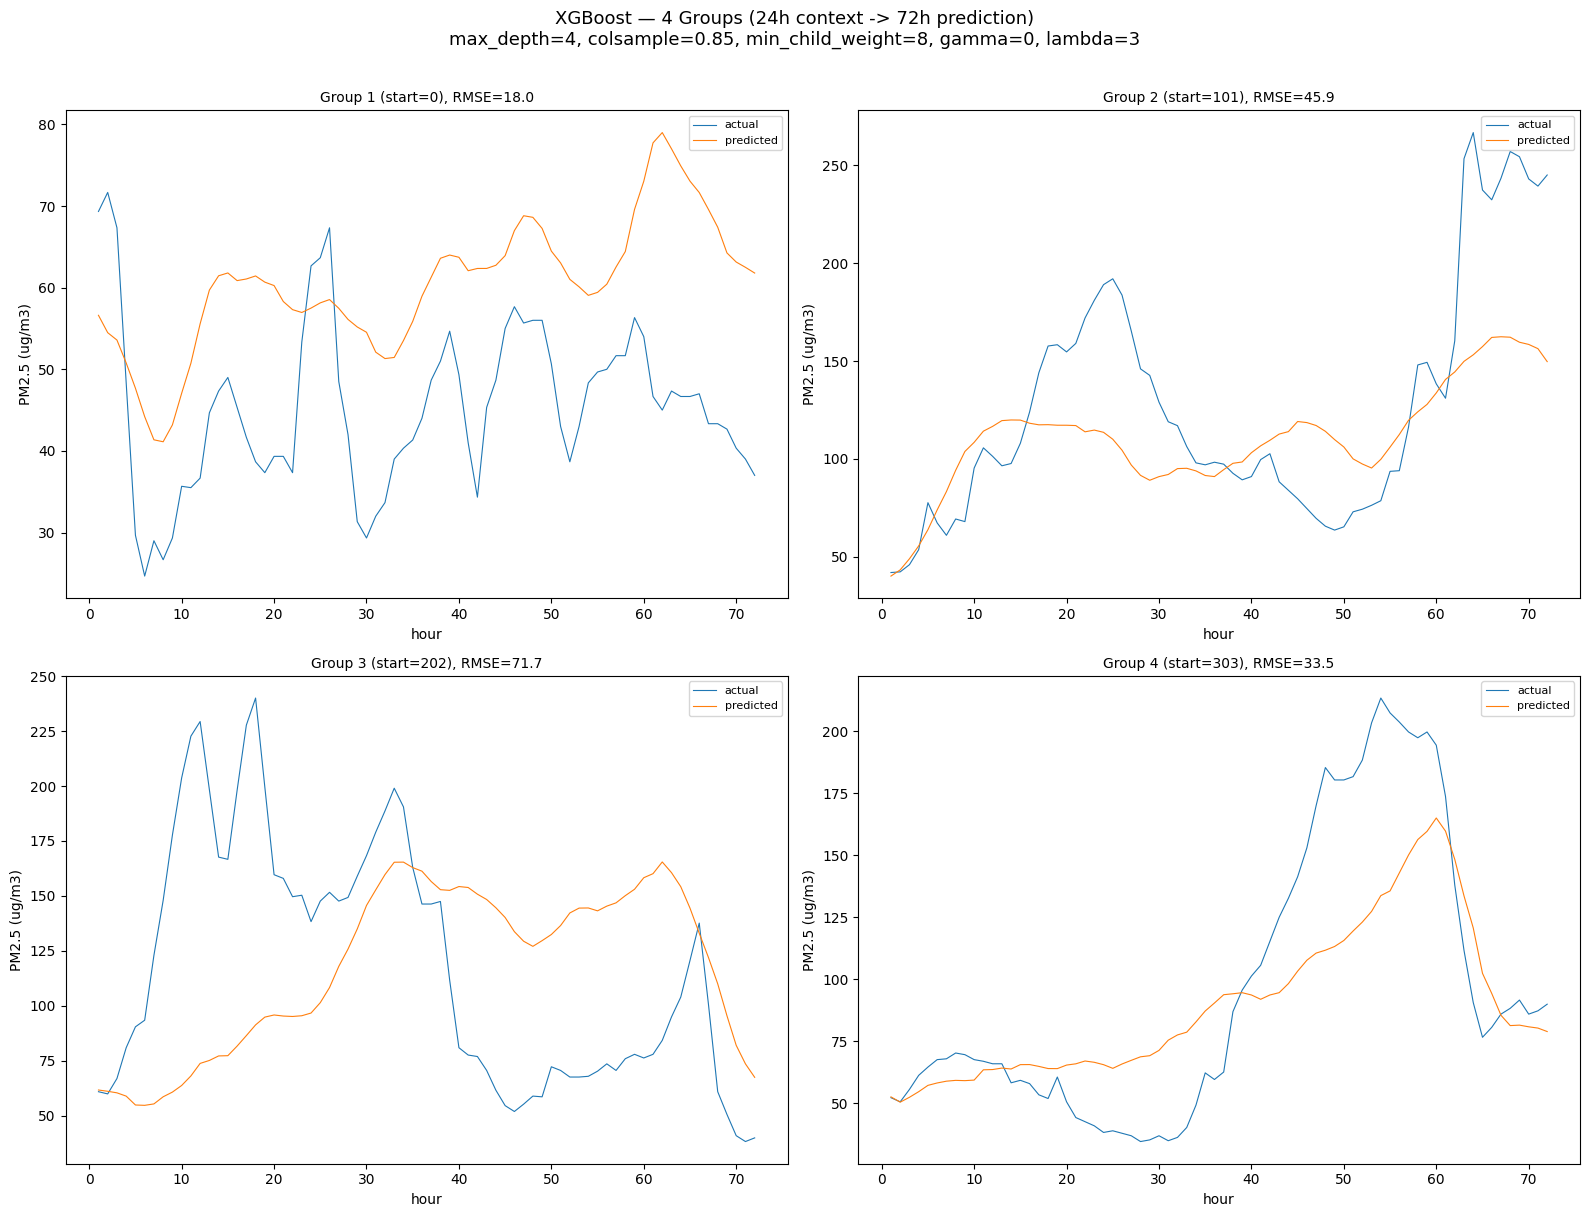


=== 4 组 RMSE 汇总 ===
  Group 1: RMSE = 17.95
  Group 2: RMSE = 45.89
  Group 3: RMSE = 71.67
  Group 4: RMSE = 33.45

平均 RMSE = 42.24


In [23]:
# ============================================================
# 4 组评估: 每组 24h 上下文 + 72h 预测
# pm_ave 在 log 空间训练/预测, 最后用 expm1 还原 (已移除 σ²/2 偏置修正)
# rolling 统计量在预测时动态重算 (防止偷看未来真实值)
#   -> std 设下限保护 (修复隐患2: 防 OOD 发散)
# 评估指标: RMSE
# ============================================================
N_GROUPS = 4
N_CONTEXT = 24
N_PREDICT = 72
STRIDE = (len(df_test) - N_CONTEXT - N_PREDICT) // (N_GROUPS - 1)
print(f'测试集: {len(df_test)} 行 | {N_GROUPS} 组 | 步长 STRIDE={STRIDE}')

# 预提取测试集数组 (外生变量用真实值, PM2.5 用 pm_series 动态预测)
weather_test = df_test[WEATHER_COLS].values               # (n, 7)
weather_mean6_test = df_test[WEATHER_MEAN6_COLS].values   # (n, 7)
time_test = df_test[TIME_COLS].values                     # (n, 6)
cbwd_test = df_test[CBWD_COLS].values                     # (n, 5)
pm_test = df_test['pm_ave'].values                        # log 空间

all_rmses = []
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for g in range(N_GROUPS):
    start = g * STRIDE
    # pm_series: log 空间的 96 小时 pm_ave (前 24 为上下文真实值)
    pm_series = np.zeros(N_CONTEXT + N_PREDICT)
    pm_series[:N_CONTEXT] = pm_test[start:start + N_CONTEXT]

    # 多步预测 72 小时 (在 log 空间进行)
    for i in range(N_PREDICT):
        T = start + N_CONTEXT + i   # 预测时刻在 df_test 中的绝对索引
        pos = N_CONTEXT + i         # 在 pm_series 中的位置

        row = []
        # 1) PM2.5 特定滞后 (从 pm_series 取, 防止偷看未来)
        for l in PM_LAGS:
            row.append(pm_series[pos - l])
        # 2) 气象当前时刻 T (外生变量, 真实值)
        row.extend(weather_test[T])
        # 3) 气象 6h 均值 (precomputed, 真实值)
        row.extend(weather_mean6_test[T])
        # 4) 时间周期编码 (预测时刻 T)
        row.extend(time_test[T])
        # 5) 风向独热 (预测时刻 T)
        row.extend(cbwd_test[T])
        # 6) PM rolling 统计 (动态重算, 用 pm_series, 防作弊)
        #    在最新观测 pos-1 处计算 (与训练时 rolling[T-1] 一致)
        roll6_data  = pm_series[max(0, pos - 6):pos]   # 最多 6 个值
        roll24_data = pm_series[max(0, pos - 24):pos]  # 最多 24 个值
        std6  = np.std(roll6_data,  ddof=1) if len(roll6_data)  > 1 else 0.0
        std24 = np.std(roll24_data, ddof=1) if len(roll24_data) > 1 else 0.0
        # 修复隐患2: 下限保护, 防递归中后期 std 塌陷 -> OOD 发散
        row.append(np.mean(roll6_data))
        row.append(max(std6,  STD_FLOOR_6))
        row.append(np.mean(roll24_data))
        row.append(max(std24, STD_FLOOR_24))
        # 7) 趋势特征 (从 pm_series 动态计算)
        row.append(pm_series[pos - 1] - pm_series[pos - 3])
        row.append(pm_series[pos - 1] - pm_series[pos - 24])

        dpredict = xgb.DMatrix(np.array(row).reshape(1, -1),
                               feature_names=FEATURE_NAMES)
        pred = bst.predict(
            dpredict, iteration_range=(0, bst.best_iteration + 1))[0]
        # 预测裁剪: 限制在训练集 1%-99% 分位数内, 防递归发散
        pm_series[pos] = np.clip(pred, CLIP_LO, CLIP_HI)

    # --- Log 还原 (修复隐患3: 去除 σ²/2 偏置修正, 直接 expm1) ---
    # 1 步验证集残差方差不适用于 72 步递归; 指数放大会惩罚峰值
    preds_log  = pm_series[N_CONTEXT:]
    actual_log = pm_test[start + N_CONTEXT:start + N_CONTEXT + N_PREDICT]
    preds  = np.expm1(preds_log)
    actual = np.expm1(actual_log)

    # RMSE
    rmse = np.sqrt(((preds - actual) ** 2).mean())
    all_rmses.append(rmse)

    ax = axes[g]
    hours = np.arange(1, N_PREDICT + 1)
    ax.plot(hours, actual, linewidth=0.8, label='actual')
    ax.plot(hours, preds, linewidth=0.8, label='predicted')
    ax.set_title(f'Group {g+1} (start={start}), RMSE={rmse:.1f}', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('hour')
    ax.set_ylabel('PM2.5 (ug/m3)')

plt.suptitle(f'XGBoost — {N_GROUPS} Groups (24h context -> 72h prediction)\n'
             f'max_depth=4, colsample=0.85, min_child_weight=8, gamma=0, lambda=3',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'\n=== {N_GROUPS} 组 RMSE 汇总 ===')
for g, rmse in enumerate(all_rmses):
    print(f'  Group {g+1}: RMSE = {rmse:.2f}')
print(f'\n平均 RMSE = {np.mean(all_rmses):.2f}')